In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
df = pd.read_csv("loan_data.csv")

print(df.head())
print(df.info())

   Gender Married     Education Self_Employed  ApplicantIncome  \
0    Male     Yes  Not Graduate           Yes             6468   
1  Female      No  Not Graduate            No             7417   
2    Male     Yes      Graduate            No            13644   
3    Male     Yes      Graduate            No            10287   
4    Male      No  Not Graduate           Yes             2228   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               7409         368               240               0   
1               7418          97               240               1   
2               4972         110               120               0   
3               5124         386               180               0   
4               7286          75               120               0   

  Property_Area Loan_Status  
0         Rural           N  
1         Rural           Y  
2         Rural           Y  
3     Semiurban           N  
4         Urban           N  
<c

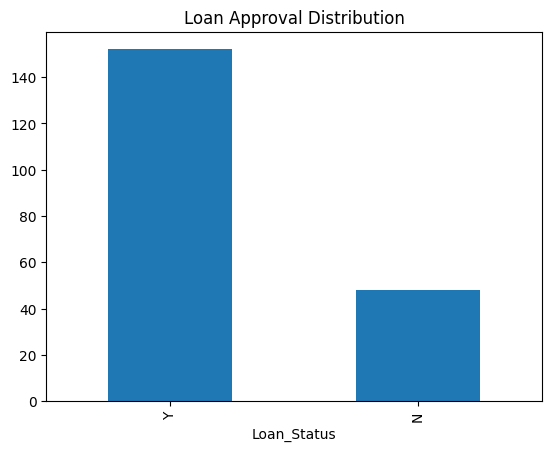

In [7]:
df = pd.read_csv("loan_data.csv")
df["Loan_Status"].value_counts().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.show()

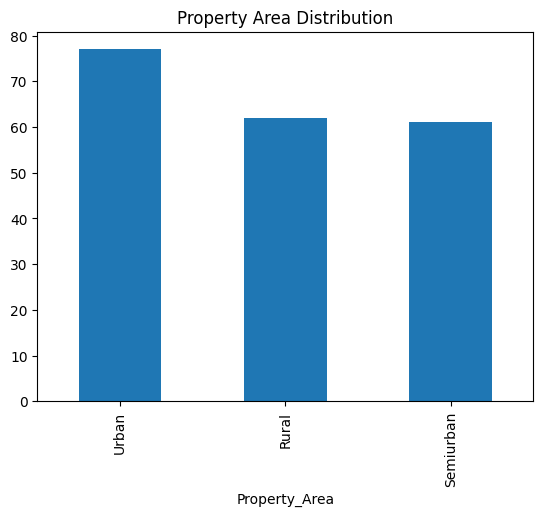

In [5]:
df["Property_Area"].value_counts().plot(kind="bar")
plt.title("Property Area Distribution")
plt.show()

In [13]:
encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model1 = LogisticRegression(max_iter=5000)

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1))
model2 = RandomForestClassifier()

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred2))
print("Confusion Matrix (Random Forest):")

print(confusion_matrix(y_test, pred2))

Logistic Regression Accuracy: 0.875
Random Forest Accuracy: 1.0
Confusion Matrix (Random Forest):
[[ 9  0]
 [ 0 31]]


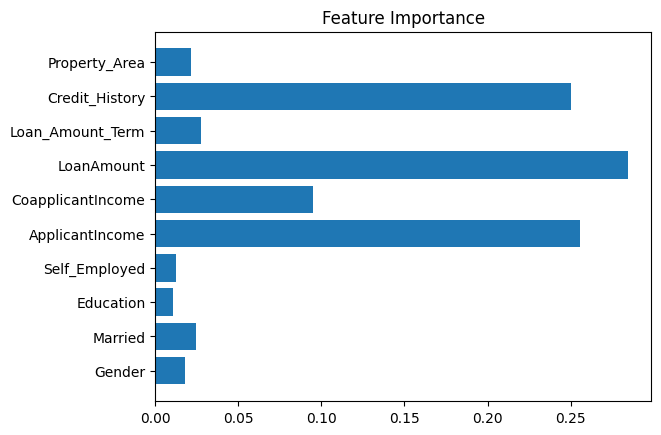

In [12]:
importance = model2.feature_importances_

features = X.columns

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()